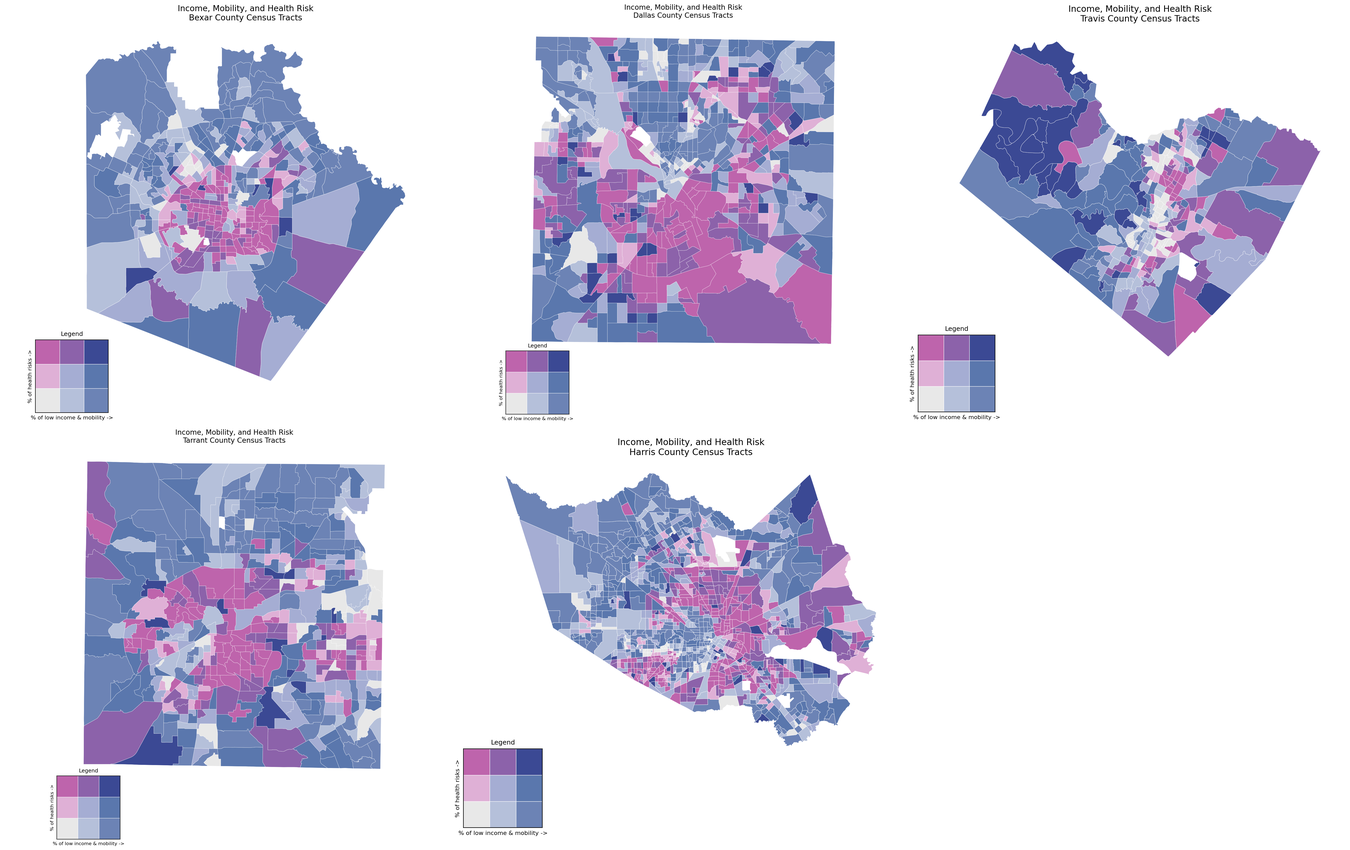

In [4]:
from PIL import Image

filenames = [
    "bexar_bivariate_choropleth.png",
    "dallas_bivariate_choropleth.png",
    "travis_bivariate_choropleth.png",
    "tarrant_bivariate_choropleth.png",
    "harris_bivariate_choropleth.png"
]
images = [Image.open(f) for f in filenames]

thumb_w, thumb_h = 450, 425
resized_images = []
for img in images:
    img_copy = img.copy()
    img_copy.thumbnail((thumb_w, thumb_h), Image.Resampling.LANCZOS)  # preserves aspect ratio
    # paste centered onto a white cell of consistent size
    cell = Image.new("RGB", (thumb_w, thumb_h), "white")
    x = (thumb_w - img_copy.width) // 2
    y = (thumb_h - img_copy.height) // 2
    cell.paste(img_copy, (x, y))
    resized_images.append(cell)

grid_canvas = Image.new("RGB", (thumb_w * 3, thumb_h * 2), "white")
positions = [
    (0, 0), (thumb_w, 0), (thumb_w * 2, 0),
    (0, thumb_h), (thumb_w, thumb_h)
]
for img, pos in zip(resized_images, positions):
    grid_canvas.paste(img, pos)

grid_canvas.show()
grid_canvas.save("all_metros_bivariate_grid.png", dpi=(300, 300))